In [ ]:
!pip install -q osmnx networkx folium pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.8 MB/s eta 0:00:00


In [ ]:
import math
import random
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import folium

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

try:
    import osmnx as ox
    OSMNX_OK = True
    print("OSMnx disponible. Se usará la red vial real de OpenStreetMap.")
except Exception as e:
    OSMNX_OK = False
    print(f"OSMnx no disponible ({e}). Se usará distancia euclidiana como respaldo.")

OSMnx disponible. Se usará la red vial real de OpenStreetMap.


In [ ]:
SEMILLA = 42
random.seed(SEMILLA)

TAM_POBLACION = 100

GENERACIONES = 300

PROB_CRUCE = 0.90

PROB_MUTACION_SWAP = 0.20

PROB_MUTACION_INVERSION = 0.10

ELITISMO = 2

TAM_TORNEO = 4

PACIENCIA = 60

print("Parámetros cargados correctamente.")
print(f"  Población: {TAM_POBLACION} | Generaciones: {GENERACIONES} | "
      f"P_cruce: {PROB_CRUCE} | P_swap: {PROB_MUTACION_SWAP} | P_inv: {PROB_MUTACION_INVERSION}")

Parámetros cargados correctamente.
  Población: 100 | Generaciones: 300 | P_cruce: 0.9 | P_swap: 0.2 | P_inv: 0.1


In [ ]:
PUNTOS = [
    {"id": 0,  "nombre": "INICIO (Depot)",        "lat": -6.7952778, "lng": -79.8843056},
    {"id": 1,  "nombre": "Punto 1",               "lat": -6.7940556, "lng": -79.8846389},
    {"id": 2,  "nombre": "Punto 2",               "lat": -6.7933611, "lng": -79.8843889},
    {"id": 3,  "nombre": "Punto 3",               "lat": -6.7922778, "lng": -79.8834444},
    {"id": 4,  "nombre": "Punto 4",               "lat": -6.7914167, "lng": -79.8835278},
    {"id": 5,  "nombre": "Punto 5",               "lat": -6.7905556, "lng": -79.8835833},
    {"id": 6,  "nombre": "Punto 6",               "lat": -6.7905833, "lng": -79.8845556},
    {"id": 7,  "nombre": "Punto 7",               "lat": -6.7909722, "lng": -79.8853611},
    {"id": 8,  "nombre": "Punto 8",               "lat": -6.7914722, "lng": -79.8848333},
    {"id": 9,  "nombre": "Punto 9",               "lat": -6.7910278, "lng": -79.8866667},
    {"id": 10, "nombre": "Punto 10",              "lat": -6.7910556, "lng": -79.8892500},
    {"id": 11, "nombre": "Punto 11",              "lat": -6.7899167, "lng": -79.8880833},
    {"id": 12, "nombre": "Punto 12",              "lat": -6.7891667, "lng": -79.8865000},
    {"id": 13, "nombre": "Punto 13",              "lat": -6.7878611, "lng": -79.8875278},
    {"id": 14, "nombre": "Punto 14",              "lat": -6.7936389, "lng": -79.8856944},
    {"id": 15, "nombre": "Punto 15",              "lat": -6.7943889, "lng": -79.8882778},
    {"id": 16, "nombre": "Punto 16",              "lat": -6.7954444, "lng": -79.8886944},
    {"id": 17, "nombre": "Punto 17",              "lat": -6.7961389, "lng": -79.8868889},
    {"id": 18, "nombre": "Punto 18",              "lat": -6.7952222, "lng": -79.8876389},
    {"id": 19, "nombre": "Punto 19",              "lat": -6.7970000, "lng": -79.8877222},
    {"id": 20, "nombre": "FIN (Destino final)",   "lat": -6.7967222, "lng": -79.8863889},
]

IDX_INICIO = 0
IDX_FIN    = 20

INTERMEDIOS = list(range(1, 20))

df_puntos = pd.DataFrame(PUNTOS)
print(f"Total de puntos: {len(PUNTOS)} (1 inicio + 19 intermedios + 1 fin)")
display(df_puntos)

Total de puntos: 21 (1 inicio + 19 intermedios + 1 fin)


,id,nombre,lat,lng
0,0,INICIO (Depot),-6.795278,-79.884306
1,1,Punto 1,-6.794056,-79.884639
2,2,Punto 2,-6.793361,-79.884389
3,3,Punto 3,-6.792278,-79.883444
4,4,Punto 4,-6.791417,-79.883528
5,5,Punto 5,-6.790556,-79.883583
6,6,Punto 6,-6.790583,-79.884556
7,7,Punto 7,-6.790972,-79.885361
8,8,Punto 8,-6.791472,-79.884833
9,9,Punto 9,-6.791028,-79.886667


In [ ]:
def distancia_haversine(lat1, lng1, lat2, lng2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lng2 - lng1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def construir_matriz_haversine(puntos):
    n = len(puntos)
    mat = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                mat[i][j] = distancia_haversine(
                    puntos[i]["lat"], puntos[i]["lng"],
                    puntos[j]["lat"], puntos[j]["lng"]
                )
    return mat


def construir_matriz_osm(puntos):
    lats = [p["lat"] for p in puntos]
    lngs = [p["lng"] for p in puntos]
    lat_c = sum(lats) / len(lats)
    lng_c = sum(lngs) / len(lngs)

    print("Descargando red vial de OpenStreetMap...")

    G = ox.graph_from_point((lat_c, lng_c), dist=1500, network_type="drive")
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)
    print(f"Red vial descargada: {len(G.nodes)} nodos, {len(G.edges)} aristas.")


    nodos_snap = [
        ox.distance.nearest_nodes(G, p["lng"], p["lat"])
        for p in puntos
    ]

    n = len(puntos)
    mat = [[0.0] * n for _ in range(n)]

    print("Calculando distancias por red vial...")
    for i in range(n):
        for j in range(n):
            if i != j:
                try:
                    longitud = nx.shortest_path_length(
                        G, nodos_snap[i], nodos_snap[j], weight="length"
                    )
                    mat[i][j] = longitud
                except nx.NetworkXNoPath:

                    mat[i][j] = distancia_haversine(
                        puntos[i]["lat"], puntos[i]["lng"],
                        puntos[j]["lat"], puntos[j]["lng"]
                    )
    print("Matriz de distancias OSM construida.")
    return mat, G, nodos_snap


G_osm = None
nodos_snap = None

if OSMNX_OK:
    try:
        MATRIZ_DIST, G_osm, nodos_snap = construir_matriz_osm(PUNTOS)
        FUENTE_DIST = "Red vial OpenStreetMap (OSMnx)"
    except Exception as e:
        print(f"Error al usar OSMnx ({e}). Usando Haversine.")
        MATRIZ_DIST = construir_matriz_haversine(PUNTOS)
        FUENTE_DIST = "Distancia Haversine (respaldo)"
else:
    MATRIZ_DIST = construir_matriz_haversine(PUNTOS)
    FUENTE_DIST = "Distancia Haversine (respaldo)"

print(f"\nFuente de distancias: {FUENTE_DIST}")
print(f"Ejemplo – distancia INICIO → Punto 1: {MATRIZ_DIST[0][1]:.1f} m")

Descargando red vial de OpenStreetMap...
Red vial descargada: 1306 nodos, 3442 aristas.
Calculando distancias por red vial...
Matriz de distancias OSM construida.

Fuente de distancias: Red vial OpenStreetMap (OSMnx)
Ejemplo – distancia INICIO → Punto 1: 150.3 m


In [ ]:
def distancia_total_ruta(cromosoma):
    ruta_completa = [IDX_INICIO] + cromosoma + [IDX_FIN]
    distancia = 0.0
    for k in range(len(ruta_completa) - 1):
        origen  = ruta_completa[k]
        destino = ruta_completa[k + 1]
        distancia += MATRIZ_DIST[origen][destino]
    return distancia


def calcular_fitness(cromosoma):
    dist = distancia_total_ruta(cromosoma)
    return 1.0 / (dist + 1e-9)


cromosoma_ejemplo = list(range(1, 20))
dist_ejemplo = distancia_total_ruta(cromosoma_ejemplo)
fit_ejemplo  = calcular_fitness(cromosoma_ejemplo)

print("Verificación de la función fitness:")
print(f"  Cromosoma ejemplo (orden secuencial 1→19):")
print(f"  Ruta: INICIO → {cromosoma_ejemplo} → FIN")
print(f"  Distancia total: {dist_ejemplo:.2f} m  ({dist_ejemplo/1000:.3f} km)")
print(f"  Fitness: {fit_ejemplo:.8f}")

Verificación de la función fitness:
  Cromosoma ejemplo (orden secuencial 1→19):
  Ruta: INICIO → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] → FIN
  Distancia total: 4775.98 m  (4.776 km)
  Fitness: 0.00020938


In [ ]:
def crear_cromosoma():
    cromosoma = INTERMEDIOS[:]
    random.shuffle(cromosoma)
    return cromosoma


def crear_poblacion(tam):
    return [crear_cromosoma() for _ in range(tam)]

poblacion_inicial = crear_poblacion(TAM_POBLACION)

fitness_iniciales = [calcular_fitness(c) for c in poblacion_inicial]
dist_iniciales    = [distancia_total_ruta(c) for c in poblacion_inicial]

print(f"Población inicial creada: {len(poblacion_inicial)} individuos")
print(f"  Distancia mínima en población inicial: {min(dist_iniciales):.1f} m")
print(f"  Distancia máxima en población inicial: {max(dist_iniciales):.1f} m")
print(f"  Distancia promedio:                    {sum(dist_iniciales)/len(dist_iniciales):.1f} m")
print(f"  Diversidad verificada: {len(set(tuple(c) for c in poblacion_inicial))} permutaciones únicas de {TAM_POBLACION}")

Población inicial creada: 100 individuos
  Distancia mínima en población inicial: 8605.6 m
  Distancia máxima en población inicial: 14217.0 m
  Distancia promedio:                    11986.1 m
  Diversidad verificada: 100 permutaciones únicas de 100


In [ ]:
def seleccion_torneo(poblacion):
    participantes = random.sample(poblacion, TAM_TORNEO)
    ganador = max(participantes, key=calcular_fitness)
    return ganador

padre_prueba = seleccion_torneo(poblacion_inicial)
print("Selección por torneo verificada.")
print(f"  Padre seleccionado (primeros 5 genes): {padre_prueba[:5]}...")
print(f"  Distancia de la ruta seleccionada: {distancia_total_ruta(padre_prueba):.1f} m")

Selección por torneo verificada.
  Padre seleccionado (primeros 5 genes): [7, 8, 10, 5, 3]...
  Distancia de la ruta seleccionada: 11258.0 m


In [ ]:
def cruce_ox1(padre1, padre2):
    n = len(padre1)

    i1, i2 = sorted(random.sample(range(n), 2))

    def _ox(p1, p2):
        hijo = [None] * n
        hijo[i1:i2 + 1] = p1[i1:i2 + 1]
        segmento = set(hijo[i1:i2 + 1])
        pos = (i2 + 1) % n
        for gen in p2[i2 + 1:] + p2[:i2 + 1]:
            if gen not in segmento:
                hijo[pos] = gen
                segmento.add(gen)
                pos = (pos + 1) % n
        return hijo

    if random.random() < PROB_CRUCE:
        hijo1 = _ox(padre1, padre2)
        hijo2 = _ox(padre2, padre1)
    else:
        hijo1 = padre1[:]
        hijo2 = padre2[:]

    return hijo1, hijo2


p1 = list(range(1, 20))
p2 = list(range(19, 0, -1))
h1, h2 = cruce_ox1(p1, p2)

print("Cruce OX1 verificado:")
print(f"  Padre 1: {p1}")
print(f"  Padre 2: {p2}")
print(f"  Hijo 1:  {h1}")
print(f"  Hijo 2:  {h2}")
print(f"  Hijo 1 es permutación válida: {sorted(h1) == list(range(1, 20))}")
print(f"  Hijo 2 es permutación válida: {sorted(h2) == list(range(1, 20))}")

Cruce OX1 verificado:
  Padre 1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  Padre 2: [19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
  Hijo 1:  [19, 18, 17, 5, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 3, 2, 1]
  Hijo 2:  [1, 2, 3, 15, 16, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 17, 18, 19]
  Hijo 1 es permutación válida: True
  Hijo 2 es permutación válida: True


In [ ]:
def mutacion_swap(cromosoma):
    nuevo = cromosoma[:]
    if random.random() < PROB_MUTACION_SWAP:
        i, j = random.sample(range(len(nuevo)), 2)
        nuevo[i], nuevo[j] = nuevo[j], nuevo[i]
    return nuevo


def mutacion_inversion(cromosoma):
    nuevo = cromosoma[:]
    if random.random() < PROB_MUTACION_INVERSION:
        i, j = sorted(random.sample(range(len(nuevo)), 2))
        nuevo[i:j + 1] = reversed(nuevo[i:j + 1])
    return nuevo


def mutar(cromosoma):
    nuevo = mutacion_swap(cromosoma)
    nuevo = mutacion_inversion(nuevo)
    return nuevo

original = list(range(1, 20))
mutado   = mutar(original)

print("Mutación verificada:")
print(f"  Original: {original}")
print(f"  Mutado:   {mutado}")
print(f"  Sigue siendo permutación válida: {sorted(mutado) == list(range(1, 20))}")

Mutación verificada:
  Original: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  Mutado:   [1, 15, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 2, 16, 17, 18, 19]
  Sigue siendo permutación válida: True


In [ ]:
def ejecutar_ag():
    poblacion = crear_poblacion(TAM_POBLACION)

    historial = []
    mejor_distancia_global = float("inf")
    generaciones_sin_mejora = 0
    mejor_ruta_global = None

    for gen in range(1, GENERACIONES + 1):

        poblacion.sort(key=calcular_fitness, reverse=True)

        mejor_actual = poblacion[0]
        dist_actual  = distancia_total_ruta(mejor_actual)

        distancias_gen = [distancia_total_ruta(c) for c in poblacion]
        historial.append({
            "Generacion": gen,
            "Mejor distancia (m)": dist_actual,
            "Distancia promedio (m)": sum(distancias_gen) / len(distancias_gen),
            "Fitness mejor": calcular_fitness(mejor_actual)
        })


        if dist_actual < mejor_distancia_global:
            mejor_distancia_global = dist_actual
            mejor_ruta_global = mejor_actual[:]
            generaciones_sin_mejora = 0
        else:
            generaciones_sin_mejora += 1

        if gen % 50 == 0 or gen == 1:
            print(f"  Gen {gen:>3}: mejor = {dist_actual:.1f} m | "
                  f"global = {mejor_distancia_global:.1f} m | "
                  f"sin mejora: {generaciones_sin_mejora}")

        if generaciones_sin_mejora >= PACIENCIA:
            print(f"\nParada temprana en generación {gen} "
                  f"(sin mejora por {PACIENCIA} generaciones consecutivas).")
            break

        nueva_poblacion = [ind[:] for ind in poblacion[:ELITISMO]]

        while len(nueva_poblacion) < TAM_POBLACION:

            padre1 = seleccion_torneo(poblacion)
            padre2 = seleccion_torneo(poblacion)

            hijo1, hijo2 = cruce_ox1(padre1, padre2)

            nueva_poblacion.append(mutar(hijo1))
            if len(nueva_poblacion) < TAM_POBLACION:
                nueva_poblacion.append(mutar(hijo2))

        poblacion = nueva_poblacion

    return mejor_ruta_global, mejor_distancia_global, pd.DataFrame(historial)


print("Iniciando Algoritmo Genético...")
print(f"Configuración: {TAM_POBLACION} individuos | {GENERACIONES} generaciones máx.")
print("-" * 65)

mejor_ruta, mejor_distancia, historial_df = ejecutar_ag()

print("-" * 65)
print(f"\nAlgoritmo finalizado.")
print(f"Mejor distancia encontrada: {mejor_distancia:.2f} m  ({mejor_distancia/1000:.3f} km)")

Iniciando Algoritmo Genético...
Configuración: 100 individuos | 300 generaciones máx.
-----------------------------------------------------------------
  Gen   1: mejor = 8643.2 m | global = 8643.2 m | sin mejora: 0
  Gen  50: mejor = 4643.3 m | global = 4643.3 m | sin mejora: 3
  Gen 100: mejor = 4386.0 m | global = 4386.0 m | sin mejora: 25

Parada temprana en generación 135 (sin mejora por 60 generaciones consecutivas).
-----------------------------------------------------------------

Algoritmo finalizado.
Mejor distancia encontrada: 4386.03 m  (4.386 km)


In [ ]:
ruta_aleatoria    = crear_cromosoma()
dist_aleatoria    = distancia_total_ruta(ruta_aleatoria)
mejora_porcentaje = (dist_aleatoria - mejor_distancia) / dist_aleatoria * 100

ruta_completa_ids   = [IDX_INICIO] + mejor_ruta + [IDX_FIN]
ruta_completa_nombres = [PUNTOS[i]["nombre"] for i in ruta_completa_ids]

print("=" * 65)
print(" RESULTADO DEL ALGORITMO GENÉTICO")
print("=" * 65)
print(f" Fuente de distancias : {FUENTE_DIST}")
print(f" Semilla              : {SEMILLA}")
print("-" * 65)
print(f" Ruta aleatoria (referencia): {dist_aleatoria:.2f} m")
print(f" Ruta optimizada (AG):        {mejor_distancia:.2f} m")
print(f" Mejora obtenida:             {mejora_porcentaje:.1f}%")
print("-" * 65)
print(" Orden de visita optimizado:")
for i, nombre in enumerate(ruta_completa_nombres):
    print(f"   Paso {i:>2}: {nombre}")
print("=" * 65)

resumen_df = pd.DataFrame([
    {
        "Caso": "Ruta aleatoria (referencia)",
        "Cromosoma": str(ruta_aleatoria),
        "Distancia total (m)": round(dist_aleatoria, 2),
        "Distancia total (km)": round(dist_aleatoria / 1000, 3)
    },
    {
        "Caso": "Ruta optimizada por AG",
        "Cromosoma": str(mejor_ruta),
        "Distancia total (m)": round(mejor_distancia, 2),
        "Distancia total (km)": round(mejor_distancia / 1000, 3)
    }
])
display(resumen_df)

print("\nDetalle de tramos (ruta optimizada):")
detalle = []
for k in range(len(ruta_completa_ids) - 1):
    orig = ruta_completa_ids[k]
    dest = ruta_completa_ids[k + 1]
    d = MATRIZ_DIST[orig][dest]
    detalle.append({
        "Tramo": f"{k+1}",
        "Origen": PUNTOS[orig]["nombre"],
        "Destino": PUNTOS[dest]["nombre"],
        "Distancia (m)": round(d, 1)
    })
detalle_df = pd.DataFrame(detalle)
display(detalle_df)

 RESULTADO DEL ALGORITMO GENÉTICO
 Fuente de distancias : Red vial OpenStreetMap (OSMnx)
 Semilla              : 42
-----------------------------------------------------------------
 Ruta aleatoria (referencia): 11953.19 m
 Ruta optimizada (AG):        4386.03 m
 Mejora obtenida:             63.3%
-----------------------------------------------------------------
 Orden de visita optimizado:
   Paso  0: INICIO (Depot)
   Paso  1: Punto 14
   Paso  2: Punto 1
   Paso  3: Punto 2
   Paso  4: Punto 3
   Paso  5: Punto 4
   Paso  6: Punto 5
   Paso  7: Punto 6
   Paso  8: Punto 8
   Paso  9: Punto 7
   Paso 10: Punto 9
   Paso 11: Punto 12
   Paso 12: Punto 13
   Paso 13: Punto 11
   Paso 14: Punto 10
   Paso 15: Punto 15
   Paso 16: Punto 16
   Paso 17: Punto 18
   Paso 18: Punto 17
   Paso 19: Punto 19
   Paso 20: FIN (Destino final)


,Caso,Cromosoma,Distancia total (m),Distancia total (km)
0,Ruta aleatoria (referencia),"[12, 13, 10, 7, 11, 15, 1, 17, 14, 9, 6, 16, 5...",11953.19,11.953
1,Ruta optimizada por AG,"[14, 1, 2, 3, 4, 5, 6, 8, 7, 9, 12, 13, 11, 10...",4386.03,4.386



Detalle de tramos (ruta optimizada):


,Tramo,Origen,Destino,Distancia (m)
0,1,INICIO (Depot),Punto 14,302.9
1,2,Punto 14,Punto 1,152.5
2,3,Punto 1,Punto 2,75.1
3,4,Punto 2,Punto 3,207.0
4,5,Punto 3,Punto 4,96.8
5,6,Punto 4,Punto 5,206.4
6,7,Punto 5,Punto 6,299.2
7,8,Punto 6,Punto 8,154.0
8,9,Punto 8,Punto 7,101.2
9,10,Punto 7,Punto 9,144.9


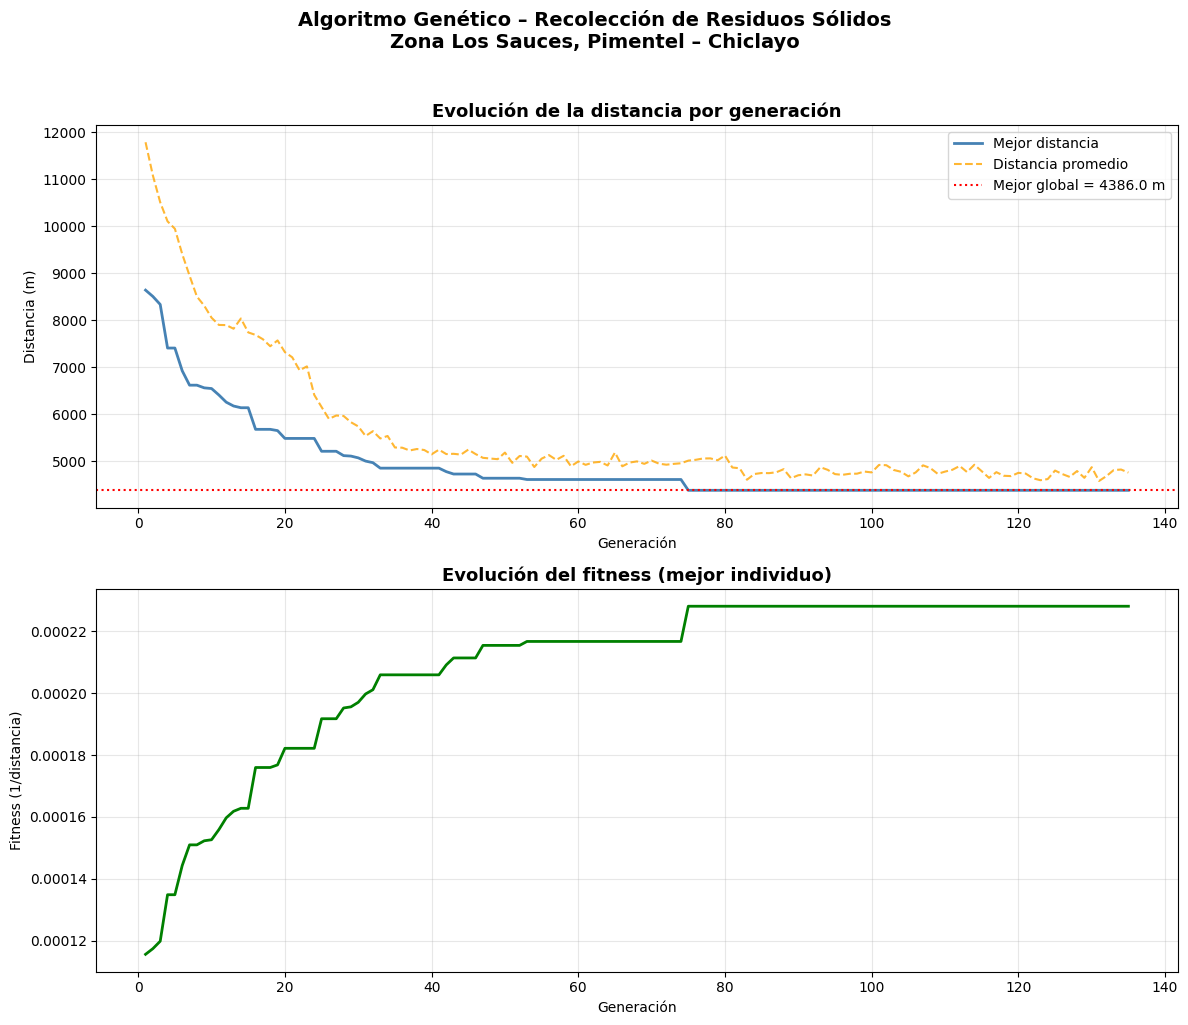

Gráfico guardado como: evolucion_ag.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(
    historial_df["Generacion"],
    historial_df["Mejor distancia (m)"],
    color="steelblue", linewidth=2, label="Mejor distancia"
)
axes[0].plot(
    historial_df["Generacion"],
    historial_df["Distancia promedio (m)"],
    color="orange", linewidth=1.5, linestyle="--", alpha=0.8, label="Distancia promedio"
)
axes[0].axhline(
    y=mejor_distancia, color="red", linestyle=":", linewidth=1.5,
    label=f"Mejor global = {mejor_distancia:.1f} m"
)
axes[0].set_title("Evolución de la distancia por generación", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Generación")
axes[0].set_ylabel("Distancia (m)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    historial_df["Generacion"],
    historial_df["Fitness mejor"],
    color="green", linewidth=2
)
axes[1].set_title("Evolución del fitness (mejor individuo)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Generación")
axes[1].set_ylabel("Fitness (1/distancia)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "Algoritmo Genético – Recolección de Residuos Sólidos\nZona Los Sauces, Pimentel – Chiclayo",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("evolucion_ag.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado como: evolucion_ag.png")

In [ ]:
def obtener_tramo_osm(id_origen, id_destino):
    """
    Devuelve la lista de coordenadas (lat, lng) del camino más corto
    entre dos puntos usando la red vial de OSM.
    Si OSM no está disponible, devuelve la línea directa entre los puntos.
    """
    if G_osm is not None and nodos_snap is not None:
        try:
            nodo_o = nodos_snap[id_origen]
            nodo_d = nodos_snap[id_destino]
            camino = nx.shortest_path(G_osm, nodo_o, nodo_d, weight="length")
            return [(G_osm.nodes[n]["y"], G_osm.nodes[n]["x"]) for n in camino]
        except Exception:
            pass
    return [
        (PUNTOS[id_origen]["lat"],  PUNTOS[id_origen]["lng"]),
        (PUNTOS[id_destino]["lat"], PUNTOS[id_destino]["lng"])
    ]


def crear_mapa_ruta(ruta_ids):
    lats = [PUNTOS[i]["lat"] for i in ruta_ids]
    lngs = [PUNTOS[i]["lng"] for i in ruta_ids]
    centro = (sum(lats) / len(lats), sum(lngs) / len(lngs))

    mapa = folium.Map(location=centro, zoom_start=16, tiles="OpenStreetMap")

    num_tramos = len(ruta_ids) - 1

    for k in range(num_tramos):
        orig = ruta_ids[k]
        dest = ruta_ids[k + 1]
        coords_tramo = obtener_tramo_osm(orig, dest)
        dist_tramo   = MATRIZ_DIST[orig][dest]

        folium.PolyLine(
            coords_tramo,
            weight=4,
            color="#1a73e8",
            opacity=0.85,
            tooltip=f"Tramo {k+1}: {PUNTOS[orig]['nombre']} → {PUNTOS[dest]['nombre']} | {dist_tramo:.0f} m"
        ).add_to(mapa)

    for orden, pid in enumerate(ruta_ids):
        p = PUNTOS[pid]

        if pid == IDX_INICIO:
            icono  = folium.Icon(color="green", icon="play", prefix="fa")
            etiqueta = f"INICIO | {p['nombre']}"
        elif pid == IDX_FIN:
            icono  = folium.Icon(color="red", icon="flag", prefix="fa")
            etiqueta = f"FIN | {p['nombre']}"
        else:
            icono  = folium.Icon(color="blue", icon="trash", prefix="fa")
            etiqueta = f"Paso {orden}: {p['nombre']}"

        folium.Marker(
            location=[p["lat"], p["lng"]],
            popup=folium.Popup(etiqueta, max_width=200),
            tooltip=etiqueta,
            icon=icono
        ).add_to(mapa)

        folium.Marker(
            location=[p["lat"] + 0.00005, p["lng"] + 0.00005],
            icon=folium.DivIcon(
                html=f'<div style="font-size:10px;font-weight:bold;color:#333">{orden}</div>',
                icon_size=(20, 20)
            )
        ).add_to(mapa)

    titulo_html = """
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                z-index: 1000; background: white; padding: 8px 16px;
                border-radius: 8px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
                font-family: Arial; font-size: 13px; font-weight: bold;">
        Ruta Óptima – Recolección de Residuos Sólidos<br>
        <span style="font-size:11px; font-weight:normal;">
            Zona Los Sauces, Pimentel – Chiclayo | AG (OX1 + Swap + Inversión)
        </span>
    </div>
    """
    mapa.get_root().html.add_child(folium.Element(titulo_html))

    return mapa

ruta_completa_ids = [IDX_INICIO] + mejor_ruta + [IDX_FIN]
mapa_resultado    = crear_mapa_ruta(ruta_completa_ids)

mapa_resultado.save("mapa_ruta_residuos_sauces.html")
print("Mapa guardado como: mapa_ruta_residuos_sauces.html")

display(mapa_resultado)

Mapa guardado como: mapa_ruta_residuos_sauces.html


In [ ]:
gens_ejecutadas = len(historial_df)
mejor_gen       = historial_df.loc[historial_df["Mejor distancia (m)"].idxmin(), "Generacion"]

print("=" * 65)
print(" RESUMEN PARA EL INFORME")
print(" Trabajo de Aplicación 02 – Algoritmos Genéticos")
print(" Desarrollo de Sistemas Inteligentes – USAT")
print("=" * 65)
print()
print(" CASO DE ESTUDIO")
print(f"   Zona: Los Sauces, Pimentel – Chiclayo, Perú")
print(f"   Puntos de recolección: {len(INTERMEDIOS)} (+ 1 inicio + 1 fin)")
print(f"   Fuente de distancias: {FUENTE_DIST}")
print()
print(" CONFIGURACIÓN DEL ALGORITMO GENÉTICO")
print(f"   Representación: permutación de ruta (path representation)")
print(f"   Cruce: Order Crossover OX1 (Davis, 1985)")
print(f"   Mutación: Swap + Simple Inversion Mutation (SIM)")
print(f"   Selección: Torneo de {TAM_TORNEO} individuos")
print(f"   Elitismo: {ELITISMO} individuos")
print(f"   Tamaño de población: {TAM_POBLACION}")
print(f"   Generaciones máx.: {GENERACIONES}")
print(f"   Prob. cruce: {PROB_CRUCE} | Prob. swap: {PROB_MUTACION_SWAP} | Prob. inv.: {PROB_MUTACION_INVERSION}")
print(f"   Semilla: {SEMILLA}")
print()
print(" RESULTADOS")
print(f"   Generaciones ejecutadas: {gens_ejecutadas}")
print(f"   Generación donde se halló la mejor ruta: {mejor_gen}")
print(f"   Distancia ruta aleatoria (referencia): {dist_aleatoria:.2f} m ({dist_aleatoria/1000:.3f} km)")
print(f"   Distancia ruta optimizada (AG):        {mejor_distancia:.2f} m ({mejor_distancia/1000:.3f} km)")
print(f"   Mejora obtenida:                       {mejora_porcentaje:.2f}%")
print()
print(" ORDEN DE VISITA ÓPTIMO")
for i, pid in enumerate(ruta_completa_ids):
    print(f"   {i:>2}. {PUNTOS[pid]['nombre']:<30}  "
          f"lat={PUNTOS[pid]['lat']:.7f}, lng={PUNTOS[pid]['lng']:.7f}")
print("=" * 65)

print("\nÚltimas 10 generaciones del historial:")
display(historial_df.tail(10))

 RESUMEN PARA EL INFORME
 Trabajo de Aplicación 02 – Algoritmos Genéticos
 Desarrollo de Sistemas Inteligentes – USAT

 CASO DE ESTUDIO
   Zona: Los Sauces, Pimentel – Chiclayo, Perú
   Puntos de recolección: 19 (+ 1 inicio + 1 fin)
   Fuente de distancias: Red vial OpenStreetMap (OSMnx)

 CONFIGURACIÓN DEL ALGORITMO GENÉTICO
   Representación: permutación de ruta (path representation)
   Cruce: Order Crossover OX1 (Davis, 1985)
   Mutación: Swap + Simple Inversion Mutation (SIM)
   Selección: Torneo de 4 individuos
   Elitismo: 2 individuos
   Tamaño de población: 100
   Generaciones máx.: 300
   Prob. cruce: 0.9 | Prob. swap: 0.2 | Prob. inv.: 0.1
   Semilla: 42

 RESULTADOS
   Generaciones ejecutadas: 135
   Generación donde se halló la mejor ruta: 75
   Distancia ruta aleatoria (referencia): 11953.19 m (11.953 km)
   Distancia ruta optimizada (AG):        4386.03 m (4.386 km)
   Mejora obtenida:                       63.31%

 ORDEN DE VISITA ÓPTIMO
    0. INICIO (Depot)            

,Generacion,Mejor distancia (m),Distancia promedio (m),Fitness mejor
125,126,4386.031868,4731.115518,0.000228
126,127,4386.031868,4670.949763,0.000228
127,128,4386.031868,4795.564031,0.000228
128,129,4386.031868,4651.621822,0.000228
129,130,4386.031868,4877.557434,0.000228
130,131,4386.031868,4585.094784,0.000228
131,132,4386.031868,4687.848895,0.000228
132,133,4386.031868,4816.592600,0.000228
133,134,4386.031868,4828.082867,0.000228
134,135,4386.031868,4763.404000,0.000228
